In [ ]:
# Load and check what is inside
import os
import torch

from class_based_implementation.train_model import objective, MODEL_CLASSES, LOSS_FUNCTIONS # Import mappings too
from maren_data.helpers import choose_data_params

sampler_type = "grid"
location = "vast" # vast or scratch


# Save the ones that ran correctly
successful_models = {}
data = "shd"
seeds = [1, 2, 3, 4, 5]
# Defaults
gamma_init_type = "rand"
gamma_fixed = False
percent_data = [0.25, 0.5, 1.0]
if data == "shd":
    num_hidden = [256, 128, 64]
elif data == "randman":
    num_hidden = [128, 64, 20]
    # Adjust these as needed
    num_classes = 2
    num_dim = 2
    alpha = 3

missing = {}
# Add model classes to dictionary with test accuracy values (we'll take averages at the end)
for model_name in MODEL_CLASSES.keys():
    print(f"Evaluating model: {model_name}")
    successful_models[model_name] = {}
    missing[model_name] = {}    
    if "Hybrid" in model_name and "Flexible" not in model_name:
        percents = [0.25, 0.5, 0.75, 0.8, 0.85, 0.9, 0.95]
    else:
        percents = [None]
    if "NSN" in model_name:
        nsn_reset = [True, False]
    else:
        nsn_reset = [True]
    for percent in percents:
        successful_models[model_name][percent] = {}
        missing[model_name][percent] = {}
        for pct_data in percent_data:
            successful_models[model_name][percent][pct_data] = {}
            missing[model_name][percent][pct_data] = {}
            for n_hidden in num_hidden:
                successful_models[model_name][percent][pct_data][n_hidden] = {}
                missing[model_name][percent][pct_data][n_hidden] = {}
                # Check per-seed whether the trained checkpoint exists.
                for n in nsn_reset:
                    successful_models[model_name][percent][pct_data][n_hidden][n] = []
                    missing[model_name][percent][pct_data][n_hidden][n] = []
                    for seed in seeds:
                        if data == "shd":
                            base_dir = f"/{location}/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        elif data == "randman":
                            base_dir = f"/{location}/nar8991/snn/training_results/randman/{num_dim}_d/{num_classes}_classes/{alpha}/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        else:
                            base_dir = None

                        if n == True:
                           base_dir = os.path.join(base_dir, 'best_model_of_study.ckpt')
                        else:
                           base_dir = os.path.join(base_dir, 'reset_nsn_False', 'best_model_of_study.ckpt')
                        if os.path.exists(base_dir):
                            successful_models[model_name][percent][pct_data][n_hidden][n].append(seed)
                        else:
                            missing[model_name][percent][pct_data][n_hidden][n].append(seed)
                            print(f"Missing model file for seed {seed} at {base_dir}")


In [ ]:
import optuna, os
def find_best_checkpoint_path(study_dir_or_db):
    # accept either a directory containing optuna_study.db or the .db path itself
    if os.path.isdir(study_dir_or_db):
        db_path = os.path.join(study_dir_or_db, "optuna_study.db")
        study_dir = study_dir_or_db
    else:
        db_path = study_dir_or_db
        study_dir = os.path.dirname(db_path)

    if not os.path.exists(db_path):
        print("optuna DB not found at:", db_path)
        return None

    storage = f"sqlite:///{db_path}"

    # get study summaries (works across Optuna versions)
    summaries = optuna.study.get_all_study_summaries(storage=storage)
    if not summaries:
        print("No studies found in DB:", db_path)
        return None

    print("Available studies:", [s.study_name for s in summaries])
    # choose the first study (adjust if you know the name)
    study_name = summaries[0].study_name
    print("Loading study:", study_name)
    study = optuna.load_study(study_name=study_name, storage=storage)
    best = study.best_trial
    print("Best trial number:", best.number)
    print("Best trial value:", best.value)
    print("User attributes on best trial:", best.user_attrs)

    # try recorded attr first
    best_ckpt = best.user_attrs.get("best_checkpoint_path")
    resolved = None
    if best_ckpt:
        resolved = best_ckpt if os.path.isabs(best_ckpt) else os.path.join(study_dir, best_ckpt)
        print("Recorded best_checkpoint_path:", best_ckpt)
        print("Resolved path:", resolved, "Exists:", os.path.exists(resolved))
        if os.path.exists(resolved):
            # ensure standardized symlink exists pointing to this resolved path
            try:
                symlink_target = os.path.join(study_dir, "best_model_of_study.ckpt")
                if os.path.exists(symlink_target) or os.path.islink(symlink_target):
                    os.remove(symlink_target)
                rel = os.path.relpath(resolved, study_dir)
                os.symlink(rel, symlink_target)
                print("Created symlink:", symlink_target, "->", rel)
            except Exception as e:
                print("Could not create symlink for recorded checkpoint:", e)
            return resolved
        else:
            resolved = None

    # If attr missing or file not present, inspect .ckpt files and prefer filenames encoding loss
    print("No valid best_checkpoint_path found in user_attrs or file missing. Scanning for .ckpt files under", study_dir)
    candidates = []
    import re
    for root, _, files in os.walk(study_dir):
        for f in files:
            if not f.endswith(".ckpt"):
                continue
            p = os.path.join(root, f)
            m = re.search(r"(?:val[_-]?loss|loss)[=._-]?([0-9]+(?:\.[0-9]+)?)", f, flags=re.IGNORECASE)
            loss_val = None
            if m:
                try:
                    loss_val = float(m.group(1))
                except Exception:
                    loss_val = None
            candidates.append({"path": p, "mtime": os.path.getmtime(p), "loss": loss_val, "fname": f})

    if not candidates:
        print("No .ckpt files found.")
        return None

    # prefer explicit loss in filename (minimize), else most recent
    loss_candidates = [c for c in candidates if c["loss"] is not None]
    if loss_candidates:
        loss_candidates.sort(key=lambda c: c["loss"])
        chosen = loss_candidates[0]
        print("Chosen by filename-encoded loss:", chosen["path"], "loss=", chosen["loss"])
    else:
        candidates.sort(key=lambda c: c["mtime"], reverse=True)
        chosen = candidates[0]
        print("No loss values found in filenames. Chosen most-recent .ckpt:", chosen["path"], "mtime=", chosen["mtime"])

    # create standardized symlink best_model_of_study.ckpt in study_dir
    try:
        symlink_target = os.path.join(study_dir, "best_model_of_study.ckpt")
        if os.path.exists(symlink_target) or os.path.islink(symlink_target):
            os.remove(symlink_target)
        rel = os.path.relpath(chosen["path"], study_dir)
        os.symlink(rel, symlink_target)
        print("Created symlink:", symlink_target, "->", rel)
    except Exception as e:
        print("Warning: Could not create symbolic link for chosen checkpoint:", e)

    return chosen["path"]


In [ ]:
# final_candidates = {}
# for model_name, percent_dict in missing.items():
#     final_candidates[model_name] = {}
#     for percent, pct_data_dict in percent_dict.items():
#         final_candidates[model_name][percent] = {}
#         for pct_data, n_hidden_dict in pct_data_dict.items():
#             final_candidates[model_name][percent][pct_data] = {}
#             for n_hidden, reset_nsn_dict in n_hidden_dict.items():
#                 final_candidates[model_name][percent][pct_data][n_hidden] = {}
#                 for reset_nsn_key, seed_list in reset_nsn_dict.items():
#                     final_candidates[model_name][percent][pct_data][n_hidden][reset_nsn_key] = []
#                     for seed in seed_list:
#                         print(base_dir)
#                         if data == "shd":
#                             base_dir = f"/{location}/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
#                         elif data == "randman":
#                             base_dir = f"/{location}/nar8991/snn/training_results/randman/{num_dim}_d/{num_classes}_classes/{alpha}/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/20_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
#                         if reset_nsn_key:
#                             path = base_dir
#                         else:
#                             path = os.path.join(base_dir, 'reset_nsn_False')
#                         final_candidates[model_name][percent][pct_data][n_hidden][reset_nsn_key].append(find_best_checkpoint_path(path))


In [ ]:
missing['Hybrid_NSN_SNN_V1_same_layer'][0.5]

In [ ]:
# # Print out all the ones that aren't None
# for model_name, percent_dict in final_candidates.items():
#     for percent, pct_data_dict in percent_dict.items():
#         for pct_data, n_hidden_dict in pct_data_dict.items():
#             for n_hidden, reset_nsn_dict in n_hidden_dict.items():
#                 for reset_nsn_key, seed_list in reset_nsn_dict.items():
#                     for seed in seed_list:
#                         if seed is not None:
#                             print(f"Model: {model_name}, Percent: {percent}, Pct Data: {pct_data}, N Hidden: {n_hidden}, Reset NSN: {reset_nsn_key}, Seed: {seed}")

In [ ]:
from test_visualizations.utils import get_randman_test_data, get_shd_test_data
if data == "shd":
    test_loader = get_shd_test_data()
elif data == "randman":
    test_loader = get_randman_test_data(num_dim=num_dim, num_classes=num_classes, alpha=alpha)
else:
    raise ValueError("Data must be 'shd' or 'randman'")

In [ ]:
from tqdm import tqdm

def compute_accuracy(model, test_loader=test_loader):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.test_accuracy.reset()
    model.to(device)
    model.zero_grad()
    # criterion = nn.CrossEntropyLoss()
    for inputs, targets in tqdm(test_loader, desc="Testing"):
        inputs, targets = inputs.to(device), targets.to(device)
        predictions, _, _, _ = model(inputs)
        logit_output, _ = torch.max(predictions, dim=1)
        model.test_accuracy.update(logit_output, targets)
    test_acc = model.test_accuracy.compute().item()
    return test_acc

In [ ]:
successful_models['SNN'][None]

In [ ]:
data

In [ ]:
final_test_accuracies = {}

for model_name, percent_dict in successful_models.items():
    final_test_accuracies[model_name] = {}
    for percent, pct_data_dict in percent_dict.items():
        final_test_accuracies[model_name][percent] = {}
        for pct_data, n_hidden_dict in pct_data_dict.items():
            final_test_accuracies[model_name][percent][pct_data] = {}
            for n_hidden, reset_nsn_dict in n_hidden_dict.items():
                final_test_accuracies[model_name][percent][pct_data][n_hidden] = {}
                for reset_nsn_key, seed_list in reset_nsn_dict.items():
                    test_accuracies = []
                    for seed in seed_list:
                        print(base_dir)
                        if data == "shd":
                            base_dir = f"/{location}/nar8991/snn/training_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/{n_hidden}_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        elif data == "randman":
                            base_dir = f"/{location}/nar8991/snn/training_results/randman/{num_dim}_d/{num_classes}_classes/{alpha}/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/20_hidden/{pct_data}_pct_data/{percent}_percent_snn/"
                        if reset_nsn_key:
                            path = os.path.join(base_dir, "best_model_of_study.ckpt")
                        else:
                            path = os.path.join(base_dir, 'reset_nsn_False', 'best_model_of_study.ckpt')
                        model_class = MODEL_CLASSES[model_name]
                        print(f"Loading model from {path}")
                        if not os.path.exists(path):
                            print(f"Checkpoint path does not exist: {path}")
                            continue
                        model = model_class.load_from_checkpoint(path, strict=False)
                        test_acc = compute_accuracy(model, test_loader=test_loader)
                        test_accuracies.append(test_acc)
                    final_test_accuracies[model_name][percent][pct_data][n_hidden][reset_nsn_key] = test_accuracies


In [ ]:
successful_models['NSN_with_LIF_output']

In [ ]:
# final_test_accuracies = {}
# for model_name in successful_models.keys():
#     final_test_accuracies[model_name] = {}
#     for percent in successful_models[model_name].keys():
#         final_test_accuracies[model_name][percent] = []
#         for seed in successful_models[model_name][percent]:
#             path = f"/scratch/nar8991/snn/snn_ann_hybrid/optuna_results/shd/None_d/20_classes/700/cross_entropy/{model_name}/recurrent_True/seed_{seed}/{sampler_type}_sampler/256_hidden/1.0_pct_data/{percent}_percent_snn/best_model_of_study.ckpt"
#             model_class = MODEL_CLASSES[model_name]
#             print(f"Loading model from {path}")
#             model = model_class.load_from_checkpoint(path, strict=False)
#             test_acc = compute_accuracy(model, test_loader=test_loader)
#             final_test_accuracies[model_name][percent].append(test_acc)
#             print(f"Model: {model_name}, Percent: {percent}, Seed: {seed}, Test Acc: {test_acc}")

In [ ]:
final_test_accuracies.keys()

In [ ]:
final_test_accuracies['SNN_2_Layer']

In [ ]:
# Take the dictionary and convert it to a dataframe
import pandas as pd

remapping = {
    "SNN": "Standard SNN",
    "ANN_with_LIF_output": "RNN",
    "NSN_with_LIF_output": "Standard Nonspiking",
    "Hybrid_RNN_SNN_rec": "Network-to-Network Hybrid - RNN",
    "Hybrid_NSN_SNN_rec": "Network-to-Network Hybrid - Nonspiking",
    "Hybrid_RNN_SNN_V1_same_layer": "Directly Connected Hybrid - RNN",
    "Hybrid_NSN_SNN_V1_same_layer": "Biologically Inspired Hybrid Model",
}


def convert_dict_to_df(final_test_accuracies):
    df_rows = []
    for original_model_name, percent_dict in final_test_accuracies.items():
        # Determine if this is an NSN model from the original key
        is_nsn_model = ('NSN' in original_model_name)
        # Apply remapping for display
        model_name = remapping.get(original_model_name, original_model_name)

        for percent_snn, percent_data in percent_dict.items():
            for percent_data, hidden_data in percent_data.items():
                for hidden_size, nsn_dict in hidden_data.items():
                    for reset_nsn_key, accuracies in nsn_dict.items():
                        # # normalize reset_nsn_key to boolean/None: expected values like 'reset_nsn_True' or 'reset_nsn_False'
                        # nsn_reset_val = None
                        if isinstance(reset_nsn_key, str) and reset_nsn_key.startswith('reset_nsn_'):
                            key_tail = reset_nsn_key.split('reset_nsn_')[-1]
                            if key_tail == 'True':
                                nsn_reset_val = True
                            elif key_tail == 'False':
                                nsn_reset_val = False
                            # else:
                            #     nsn_reset_val = None
                        else:
                            nsn_reset_val = reset_nsn_key

                        # If this is not an NSN model, ignore any reset flag and set to None
                        if not is_nsn_model:
                            nsn_reset_val = None

                        if len(accuracies) > 0:
                            avg_acc = sum(accuracies) / len(accuracies)
                            std_acc = (sum((x - avg_acc) ** 2 for x in accuracies) / len(accuracies)) ** 0.5
                            df_rows.append({
                                "Model": model_name,
                                "Percent_SNN": percent_snn,
                                "Percent_Data": percent_data,
                                "Hidden_Size": hidden_size,
                                "mean_value": avg_acc,
                                "std_value": std_acc,
                                "nsn_reset": nsn_reset_val,
                                "count": len(accuracies)
                            })
                        else:
                            df_rows.append({
                                "Model": model_name,
                                "Percent_SNN": percent_snn,
                                "Percent_Data": percent_data,
                                "Hidden_Size": hidden_size,
                                "mean_value": None,
                                "std_value": None,
                                "nsn_reset": nsn_reset_val,
                                "count": 0
                            })
    results_df = pd.DataFrame(df_rows)
    # Ensure nsn_reset column exists and string-safe
    if 'nsn_reset' not in results_df.columns:
        results_df['nsn_reset'] = None

    # Create run_group to include nsn_reset only for NSN models so plotting treats reset variants separately
    def build_run_group(row):
        base = f"{row['Model']}"
        # if "Hybrid" in base:
        #     base += f"_pct_{row['Percent_SNN']}"
        # if (row.get('nsn_reset') is not None) and (str(row['Model']).lower().find('nsn') != -1 or True):
        #     # We stored nsn_reset only for NSN models above; this conditional guards inclusion.
        #     # The check `str(row['Model']).lower().find('nsn') != -1 or True` intentionally allows
        #     # inclusion if nsn_reset is not None. However, since we forced nsn_reset=None for
        #     # non-NSN models, this will only add the reset suffix for NSN models.
        #     return base + f"_reset_{row['nsn_reset']}"
        # else:
        #     return base
        return base

    results_df['run_group'] = results_df.apply(build_run_group, axis=1)
    results_df['metric'] = 'Test Accuracy'
    # Drop rows where mean_value is None
    # results_df.dropna(subset=['mean_value'], inplace=True)
    return results_df

results_df = convert_dict_to_df(final_test_accuracies)


In [62]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.colors as mcolors
import colorsys
from contextlib import contextmanager

@contextmanager
def _temp_fontsize(size):
    """Temporarily set matplotlib font.size; restores old rcParams afterwards."""
    if size is None:
        yield
    else:
        old = mpl.rcParams.copy()
        try:
            mpl.rcParams.update({'font.size': float(size)})
            yield
        finally:
            mpl.rcParams.update(old)

def _plot_bars(ax, x_positions, values, std_values, bar_width, label, colors=None, font_size=None):
    """Plot bars while optionally applying a temporary font size."""
    with _temp_fontsize(font_size):
        if colors is None:
            bars = ax.bar(x_positions, values, yerr=std_values, width=bar_width, label=label,
                          capsize=4, alpha=0.7, error_kw={'elinewidth':1, 'ecolor':'black'})
        else:
            bars = ax.bar(x_positions, values, yerr=std_values, width=bar_width, label=label,
                          color=colors, capsize=4, alpha=0.9, error_kw={'elinewidth':1, 'ecolor':'black'})
    return bars

def _annotate_bars(ax, bars, values, std_values, extra_labels=None, font_size=None):
    """Annotate bars using provided font size (falls back to rcParams font.size)."""
    for j, bar in enumerate(bars):
        value = values[j]
        if value is None or (isinstance(value, float) and np.isnan(value)):
            continue
        if value > 0:
            sd = std_values[j] if std_values[j] is not None else 0
            text_y_position = value + (sd if sd > 0 else 0) + 0.01
            label_text = f'{value:.3f}'
            if extra_labels and extra_labels[j]:
                label_text += extra_labels[j]
            fs = float(font_size) if font_size is not None else mpl.rcParams.get('font.size', 8)
            ax.text(bar.get_x() + bar.get_width()/2., text_y_position,
                    label_text, ha='center', va='bottom', fontsize=fs, rotation=0)


def get_model_color_map(df, base_palette='tab20'):
    """
    Return mapping: model_name -> {(percent_snn, nsn_reset): rgba}.

    preassign_colors (optional) can be:
      - dict mapping model_display_name -> color (applies to all percent/nsn_reset for that model)
      - dict mapping (model_display_name, percent, nsn_reset) -> color
      - dict mapping model_display_name -> {(percent, nsn_reset): color}
      - dict mapping original_model_key -> color  (if name_map is provided; original_model_key is mapped via name_map to display names)
    Colors can be any matplotlib-acceptable color (name, hex, RGBA tuple).

    name_map (optional): dict mapping original_model_key -> display_name (if you want to allow preassign_colors keys
                        to be the original keys instead of the display names in df['Model']).
    If name_map is None, this function will try to use a global `remapping` variable if present.
    """
    # If name_map is not provided, attempt to use global remapping if available
    if name_map is None and 'remapping' in globals():
        name_map = globals().get('remapping', None)

    # Collect unique rows for mapping in a stable order
    unique_rows = df[['Model', 'Percent_SNN', 'nsn_reset']].drop_duplicates().reset_index(drop=True)
    pairs = []
    for _, r in unique_rows.iterrows():
        model = r['Model']
        percent = None if pd.isna(r['Percent_SNN']) else r['Percent_SNN']
        nsn_reset = None if pd.isna(r['nsn_reset']) else r['nsn_reset']
        pairs.append((model, percent, nsn_reset))

    N = max(1, len(pairs))
    try:
        cmap = plt.get_cmap(base_palette)
        palette_colors = [mcolors.to_rgba(cmap(i / max(1, N - 1))) for i in range(N)]
    except Exception:
        palette_colors = [mcolors.to_rgba(colorsys.hls_to_rgb(i / N, 0.55, 0.9)) for i in range(N)]

    color_map = {}
    for idx, (model, percent, nsn_reset) in enumerate(pairs):
        col = palette_colors[idx]
        if model not in color_map:
            color_map[model] = {}
        color_map[model][(percent, nsn_reset)] = col
    return color_map

def plot_metric_distribution(df_means, metrics, ax=None, title=None, font_size=None):
    """Bar-style metric distribution. font_size sets tick/label/annotation sizes."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))
    # apply font context for ticks/labels; additionally set tick label sizes explicitly
    with _temp_fontsize(font_size):
        has_counts = 'count' in df_means.columns
        run_groups = sorted(df_means['run_group'].unique())
        run_group_labels = []
        color_map = get_model_color_map(df_means)
        for group in run_groups:
            group_df = df_means[df_means['run_group'] == group]
            lr_for_label = None
            nsn_reset_for_label = None
            if 'nsn_reset' in group_df.columns and not group_df['nsn_reset'].isna().all():
                nsn_reset_for_label = group_df['nsn_reset'].iloc[0]
            if 'val_accuracy' in group_df['metric'].values and 'learning_rate' in group_df.columns:
                lr_row = group_df[group_df['metric'] == 'val_accuracy'].iloc[0]
                lr_for_label = lr_row['learning_rate']
            elif not group_df.empty and 'learning_rate' in group_df.columns:
                lr_for_label = group_df['learning_rate'].iloc[0]
            if lr_for_label is not None:
                if nsn_reset_for_label is not None:
                    run_group_labels.append(f"{group}\n(reset: {nsn_reset_for_label}, lr: {lr_for_label:.1e})")
                else:
                    run_group_labels.append(f"{group}\n(lr: {lr_for_label:.1e})")
            else:
                if nsn_reset_for_label is not None:
                    run_group_labels.append(f"{group}\n(reset: {nsn_reset_for_label})")
                else:
                    run_group_labels.append(group)
        bar_width = 0.8 / len(metrics)
        x_positions = np.arange(len(run_groups))
        for i, metric in enumerate(metrics):
            df_metric = df_means[df_means['metric'] == metric]
            values, std_values, counts, colors = [], [], [], []
            for group in run_groups:
                group_data = df_metric[df_metric['run_group'] == group]
                if not group_data.empty:
                    v = group_data['mean_value'].iloc[0]
                    s = group_data['std_value'].iloc[0]
                    c = group_data['count'].iloc[0] if has_counts else None
                    model_name = group_data['Model'].iloc[0] if 'Model' in group_data.columns else group.split('_pct_')[0]
                    percent = group_data['Percent_SNN'].iloc[0] if 'Percent_SNN' in group_data.columns else None
                    nsn_reset = group_data['nsn_reset'].iloc[0] if 'nsn_reset' in group_data.columns else None
                    if pd.isna(percent):
                        percent = None
                    if pd.isna(nsn_reset):
                        nsn_reset = None
                    color = color_map.get(model_name)
                    values.append(v if v is not None else 0)
                    std_values.append(s if s is not None else 0)
                    counts.append(c)
                    colors.append(color)
                else:
                    values.append(0)
                    std_values.append(0)
                    counts.append(None)
                    colors.append(None)
            x_offset = x_positions + (i - len(metrics)/2 + 0.5) * bar_width
            bars = _plot_bars(ax, x_offset, values, std_values, bar_width, metric, colors=colors, font_size=font_size)
            extra_labels = [f'\n(n={int(c)})' if has_counts and c is not None else '' for c in counts]
            _annotate_bars(ax, bars, values, std_values, extra_labels, font_size=font_size)
        # set tick labels and sizes
        if font_size is not None:
            ax.set_xticks(x_positions)
            ax.set_xticklabels(run_group_labels, rotation=45, ha='right', fontsize=float(font_size))
            ax.tick_params(axis='y', labelsize=float(font_size))
        else:
            ax.set_xticks(x_positions)
            ax.set_xticklabels(run_group_labels, rotation=45, ha='right')
    ax.set_title(title)
    ax.set_ylabel('Value')
    ax.set_xlabel('Run Group (with Learning Rate)')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return ax

def plot_metric_distribution_param_based(param_name, param_range, df_means, metric, title=None, font_size=None):
    fig, ax = plt.subplots(figsize=(12, 6))
    with _temp_fontsize(font_size):
        run_groups = sorted(df_means['run_group'].unique())
        df_metric = df_means[df_means['metric'] == metric]
        bar_width = 0.8 / len(run_groups)
        x_positions = np.arange(len(param_range))
        color_map = get_model_color_map(df_means)
        for i, group in enumerate(run_groups):
            df_group = df_metric[df_metric['run_group'] == group]
            values, std_values, lrs, counts, colors = [], [], [], [], []
            if not df_group.empty and 'Model' in df_group.columns:
                model_name = df_group['Model'].iloc[0]
                percent_for_group = df_group['Percent_SNN'].iloc[0]
                nsn_reset_for_group = df_group['nsn_reset'].iloc[0] if 'nsn_reset' in df_group.columns else None
                if pd.isna(percent_for_group):
                    percent_for_group = None
                if pd.isna(nsn_reset_for_group):
                    nsn_reset_for_group = None
            else:
                model_name = group.split('_pct_')[0]
                percent_for_group = None
                nsn_reset_for_group = None
            for p_val in param_range:
                param_data = df_group[df_group[param_name] == p_val]
                if not param_data.empty:
                    values.append(param_data['mean_value'].iloc[0])
                    std_values.append(param_data['std_value'].iloc[0])
                    lrs.append(param_data['learning_rate'].iloc[0] if 'learning_rate' in param_data.columns else None)
                    counts.append(param_data['count'].iloc[0] if 'count' in param_data.columns else None)
                else:
                    values.append(0)
                    std_values.append(0)
                    lrs.append(None)
                    counts.append(None)
                colors.append(color_map.get(model_name, {}).get((percent_for_group, nsn_reset_for_group), None))
            x_offset = x_positions + (i - len(run_groups)/2 + 0.5) * bar_width
            bars = _plot_bars(ax, x_offset, values, std_values, bar_width, group, colors=colors, font_size=font_size)
            extra_labels = [
                (f'\n(lr: {lrs[j]:.1e})' if lrs[j] is not None else '') +
                (f'\n(n={int(counts[j])})' if counts[j] is not None else '')
                for j in range(len(values))
            ]
            _annotate_bars(ax, bars, values, std_values, extra_labels, font_size=font_size)
        if font_size is not None:
            ax.set_xticks(x_positions)
            ax.set_xticklabels([str(p) for p in param_range], rotation=45, ha='right', fontsize=float(font_size))
            ax.tick_params(axis='y', labelsize=float(font_size))
        else:
            ax.set_xticks(x_positions)
            ax.set_xticklabels([str(p) for p in param_range], rotation=45, ha='right')
    ax.set_title(title if title else f'{metric} Distribution by {param_name}')
    ax.set_ylabel(metric)
    ax.set_xlabel(param_name)
    ax.legend(title='Run Group', loc='center left', bbox_to_anchor=(1, 0.5))
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    return ax

def plot_metric_param_lines(param_name, param_range, df_means, metric='Test Accuracy', title=None, ax=None, marker='o', font_size=None, custom_color_map=None):
    """Line plot per run_group with optional large font_size."""
    import numpy as _np
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    run_groups = sorted(df_means['run_group'].unique())
    color_map = get_model_color_map(df_means) if custom_color_map is None else custom_color_map
    df_metric = df_means[df_means['metric'] == metric]
    with _temp_fontsize(font_size):
        for group in run_groups:
            df_group = df_metric[df_metric['run_group'] == group]
            if df_group.empty:
                continue
            model_name = df_group['Model'].iloc[0] if 'Model' in df_group.columns else group.split('_pct_')[0]
            percent_for_group = None
            nsn_reset_for_group = None
            xs = []
            ys = []
            yerrs = []
            for p_val in param_range:
                row = df_group[df_group[param_name] == p_val]
                if not row.empty:
                    val = row['mean_value'].iloc[0]
                    err = row['std_value'].iloc[0] if 'std_value' in row.columns else 0
                    ys.append(val if val is not None else _np.nan)
                    yerrs.append(err if err is not None else 0)
                else:
                    ys.append(_np.nan)
                    yerrs.append(0)
                xs.append(p_val)
            color = color_map.get(model_name)
            ax.plot(xs, ys, marker=marker, label=group, color=color, linewidth=2)
            ys_arr = _np.array([_np.nan if v is None else v for v in ys], dtype=float)
            yerrs_arr = _np.array(yerrs, dtype=float)
            mask = ~_np.isnan(ys_arr)
            if mask.any():
                ax.fill_between(_np.array(xs)[mask], ys_arr[mask]-yerrs_arr[mask], ys_arr[mask]+yerrs_arr[mask], color=color, alpha=0.18)
        ax.set_xticks(param_range)
        if font_size is not None:
            ax.set_xticklabels([str(p) for p in param_range], rotation=45, ha='right', fontsize=float(font_size))
            ax.tick_params(axis='y', labelsize=float(font_size))
        else:
            ax.set_xticklabels([str(p) for p in param_range], rotation=45, ha='right')
        ax.set_title(title if title else f'{metric} vs {param_name}')
        ax.set_xlabel(param_name)
        ax.set_ylabel(metric)

In [ ]:
custom_color_map = {
    "Standard SNN": "#1f77b4",  # blue
    "Standard Nonspiking": "#2ca02c",  # green
    "Biologically Inspired Hybrid Model": "#9467bd", # purple
}

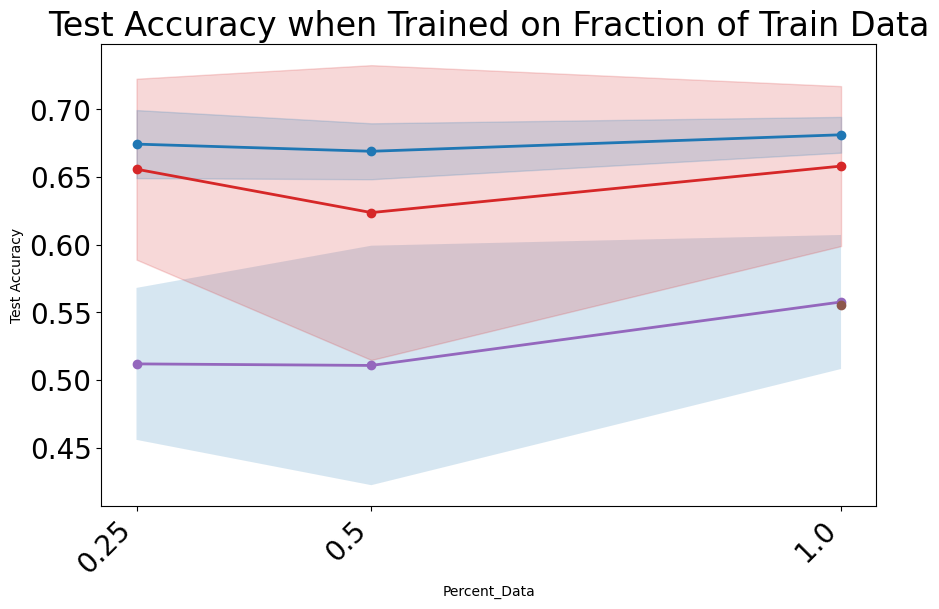

In [69]:
filtered_df = results_df[(results_df['Hidden_Size']==256) & results_df['mean_value'].notna() & (results_df['Percent_SNN'].isin([0.5]) | results_df['Percent_SNN'].isna()) & results_df['Model'].isin(['Standard SNN', 'Standard Nonspiking', 'Biologically Inspired Hybrid Model']) & results_df['nsn_reset'] != True]
plot_metric_param_lines('Percent_Data', [0.25, 0.5, 1.0], filtered_df, metric='Test Accuracy', title='Test Accuracy when Trained on Fraction of Train Data', font_size=20, custom_color_map=custom_color_map)
